## Penugasan 3 – Eksperimen Transformasi Intensitas Lain

### Deskripsi
Selain transformasi negatif, terdapat dua transformasi intensitas lain yang umum digunakan:
- **Transformasi Logaritmik**: `O = gain * log(1 + I)` — memperjelas detail pada area gelap
- **Transformasi Gamma**: `O = I ** gamma` — mengatur kecerahan secara non-linear berdasarkan nilai gamma

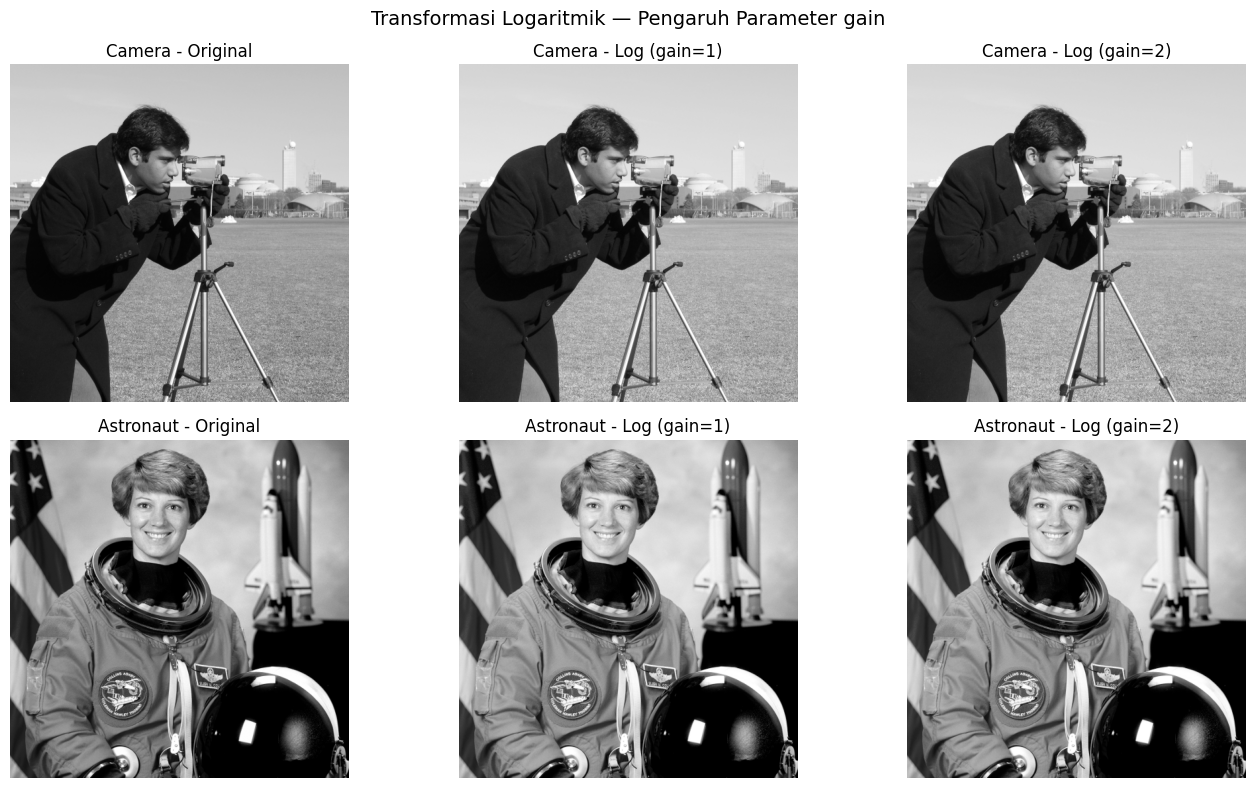

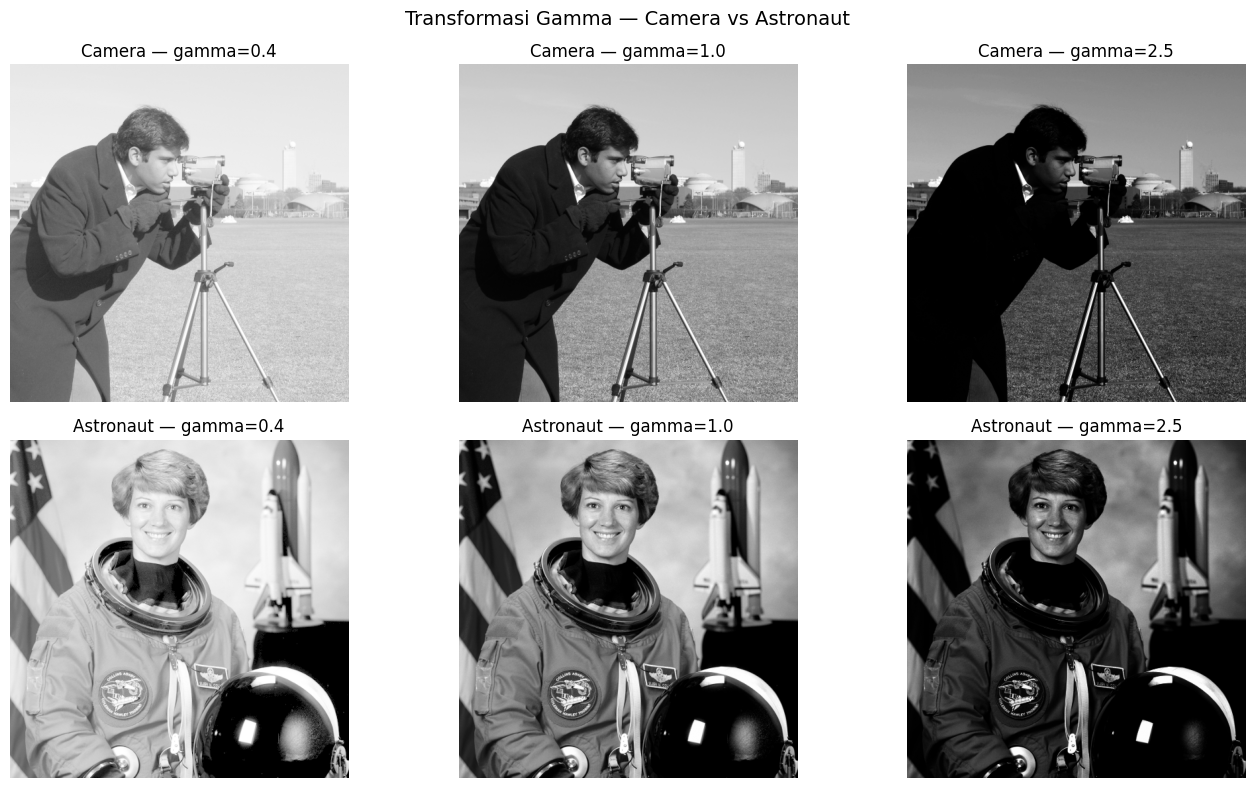

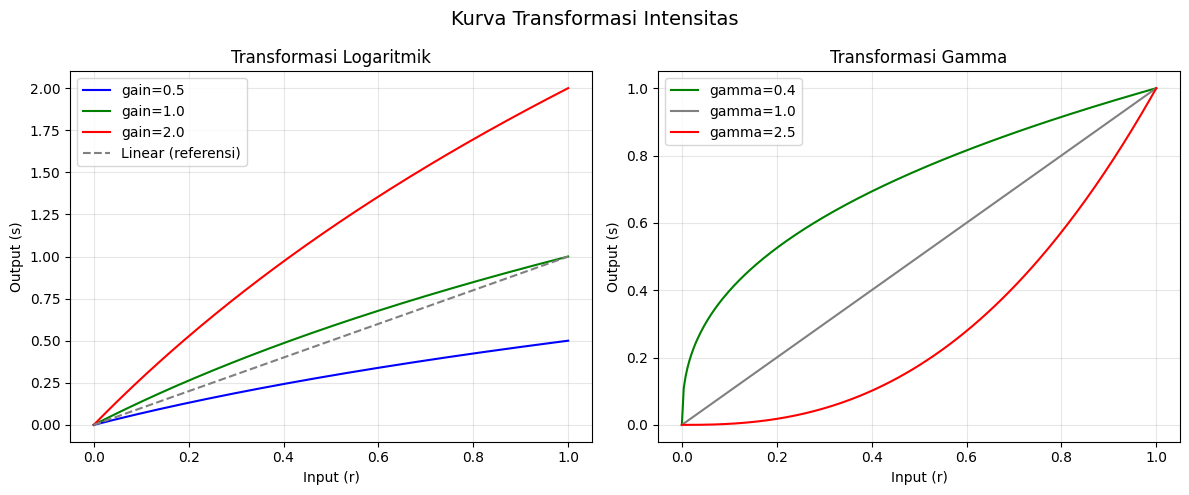

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color, exposure

# --------------------------------------------------
# PERSIAPAN CITRA
# --------------------------------------------------

# Citra 1: camera (sudah grayscale)
img_camera = img_as_float(data.camera())

# Citra 2: astronaut diubah ke grayscale
img_astronaut = img_as_float(color.rgb2gray(data.astronaut()))

# --------------------------------------------------
# 1) TRANSFORMASI LOGARITMIK
# O = gain * log(1 + I)
# --------------------------------------------------

log_camera_g1    = exposure.adjust_log(img_camera, gain=1)
log_camera_g2    = exposure.adjust_log(img_camera, gain=2)
log_astronaut_g1 = exposure.adjust_log(img_astronaut, gain=1)
log_astronaut_g2 = exposure.adjust_log(img_astronaut, gain=2)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Transformasi Logaritmik — Pengaruh Parameter gain", fontsize=14)

axes[0, 0].imshow(img_camera, cmap='gray')
axes[0, 0].set_title("Camera - Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(log_camera_g1, cmap='gray')
axes[0, 1].set_title("Camera - Log (gain=1)")
axes[0, 1].axis('off')

axes[0, 2].imshow(log_camera_g2, cmap='gray')
axes[0, 2].set_title("Camera - Log (gain=2)")
axes[0, 2].axis('off')

axes[1, 0].imshow(img_astronaut, cmap='gray')
axes[1, 0].set_title("Astronaut - Original")
axes[1, 0].axis('off')

axes[1, 1].imshow(log_astronaut_g1, cmap='gray')
axes[1, 1].set_title("Astronaut - Log (gain=1)")
axes[1, 1].axis('off')

axes[1, 2].imshow(log_astronaut_g2, cmap='gray')
axes[1, 2].set_title("Astronaut - Log (gain=2)")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) TRANSFORMASI GAMMA
# O = I ** gamma
# gamma < 1 → lebih terang
# gamma = 1 → tidak berubah
# gamma > 1 → lebih gelap
# --------------------------------------------------

gamma_values = [0.4, 1.0, 2.5]

fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
fig2.suptitle("Transformasi Gamma — Camera vs Astronaut", fontsize=14)

for i, gamma in enumerate(gamma_values):
    gamma_camera    = exposure.adjust_gamma(img_camera, gamma=gamma, gain=1)
    gamma_astronaut = exposure.adjust_gamma(img_astronaut, gamma=gamma, gain=1)

    axes2[0, i].imshow(gamma_camera, cmap='gray')
    axes2[0, i].set_title(f"Camera — gamma={gamma}")
    axes2[0, i].axis('off')

    axes2[1, i].imshow(gamma_astronaut, cmap='gray')
    axes2[1, i].set_title(f"Astronaut — gamma={gamma}")
    axes2[1, i].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) KURVA TRANSFORMASI (visualisasi matematis)
# --------------------------------------------------

x = np.linspace(0, 1, 256)

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle("Kurva Transformasi Intensitas", fontsize=14)

# Kurva log dengan berbagai gain
for gain, col in zip([0.5, 1.0, 2.0], ['blue', 'green', 'red']):
    axes3[0].plot(x, gain * np.log1p(x) / np.log1p(1), label=f'gain={gain}', color=col)
axes3[0].plot(x, x, label='Linear (referensi)', color='gray', linestyle='--')
axes3[0].set_title("Transformasi Logaritmik")
axes3[0].set_xlabel("Input (r)")
axes3[0].set_ylabel("Output (s)")
axes3[0].legend()
axes3[0].grid(True, alpha=0.3)

# Kurva gamma
for gamma, col in zip(gamma_values, ['green', 'gray', 'red']):
    axes3[1].plot(x, np.power(x, gamma), label=f'gamma={gamma}', color=col)
axes3[1].set_title("Transformasi Gamma")
axes3[1].set_xlabel("Input (r)")
axes3[1].set_ylabel("Output (s)")
axes3[1].legend()
axes3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Kesimpulan
Transformasi logaritmik menggunakan fungsi `exposure.adjust_log()` dengan rumus `O = gain * log(1 + I)` memperluas rentang intensitas pada area gelap sehingga detail yang tersembunyi menjadi lebih tampak. Nilai `gain` yang lebih besar menghasilkan output yang semakin terang secara keseluruhan.

Transformasi gamma menggunakan `exposure.adjust_gamma()` bersifat lebih fleksibel. Ketika `gamma < 1` (contoh: 0.4), citra menjadi lebih terang dan detail area gelap lebih terlihat. Ketika `gamma = 1.0`, tidak ada perubahan. Ketika `gamma > 1` (contoh: 2.5), citra menjadi lebih gelap dan histogram bergeser ke kiri. Perbedaan karakteristik antara citra `camera` dan `astronaut` menunjukkan bahwa pemilihan parameter yang tepat sangat bergantung pada distribusi intensitas citra asal.